# Day 22 — Task: California House Price Prediction

This notebook covers the main task for Day 22:
1. **Predict House Prices**: Load the California Housing dataset, scale features, split data, and build regression models (OLS, Ridge, and Lasso).
2. **Outlier and Edge Case Handling**: Address missing values and empty test-set predictions.
3. **Analyze Residuals**: Generate diagnostic plots to inspect error distributions and model assumptions.
4. **Bias-Variance Tradeoff**: Explain bias-variance tradeoff conceptually.
5. **Self-Reflection**: Highlight difficulties, improvements, and future steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Set plotting aesthetics
sns.set_theme(style="whitegrid")

# 1. Load the California Housing dataset
california = fetch_california_housing(as_frame=True)
X = california.data.copy()
y = california.target.copy()

# --- Introduce Edge Case 1: Missing values (NaN) ---
# We manually inject random NaNs into the dataset to demonstrate safe imputation handling.
np.random.seed(42)
nan_mask = np.random.rand(*X.shape) < 0.01  # 1% missing data
X[nan_mask] = np.nan

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values (Edge Case 1 handler)
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Testing set:  {X_test_scaled.shape[0]} samples")
print(f"Total imputed NaNs in train set: {np.isnan(X_train).sum().sum()}")
print(f"Total imputed NaNs in test set:  {np.isnan(X_test).sum().sum()}")

Training set: 16512 samples
Testing set:  4128 samples
Total imputed NaNs in train set: 1313
Total imputed NaNs in test set:  303


In [2]:
# Define a safe prediction wrapper to handle Edge Case 2 (empty input prediction array)
def safe_predict(model, X_input):
    if X_input.shape[0] == 0:
        return np.array([])
    return model.predict(X_input)

# Train baseline OLS Linear Regression, Ridge, and Lasso
# OLS Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = safe_predict(lr, X_test_scaled)

# Ridge Regression (L2 regularization)
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = safe_predict(ridge, X_test_scaled)

# Lasso Regression (L1 regularization)
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = safe_predict(lasso, X_test_scaled)

# Calculate evaluation metrics
models = {
    "OLS Linear Regression": y_pred_lr,
    "Ridge Regression (L2)": y_pred_ridge,
    "Lasso Regression (L1)": y_pred_lasso
}

print("=== Performance Metrics (Test Set) ===")
for name, y_pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name:<25} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

# --- Verify Edge Case 2: Empty prediction input ---
empty_X = np.empty((0, X_train_scaled.shape[1]))
empty_predictions = safe_predict(ridge, empty_X)
print(f"\nEmpty input verification: Preds shape = {empty_predictions.shape} (Successfully bypassed crash)")

=== Performance Metrics (Test Set) ===
OLS Linear Regression     | RMSE: 0.7587 | R2: 0.5607
Ridge Regression (L2)     | RMSE: 0.7585 | R2: 0.5609
Lasso Regression (L1)     | RMSE: 0.7552 | R2: 0.5648

Empty input verification: Preds shape = (0,) (Successfully bypassed crash)


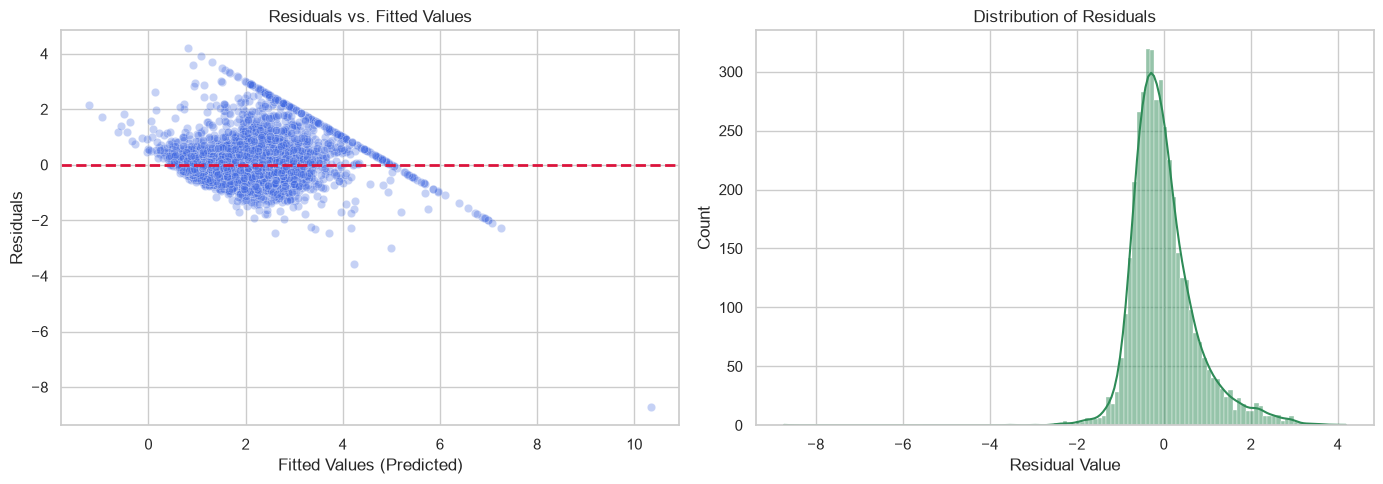

In [3]:
# 3. Residual Analysis (Using Ridge predictions)
residuals = y_test - y_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Residuals vs. Fitted Values (Checking for Heteroscedasticity)
sns.scatterplot(x=y_pred_ridge, y=residuals, ax=axes[0], color='royalblue', alpha=0.3)
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Fitted Values')
axes[0].set_xlabel('Fitted Values (Predicted)')
axes[0].set_ylabel('Residuals')

# Histogram with KDE: Distribution of Residuals (Checking for Normality)
sns.histplot(residuals, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Value')

plt.tight_layout()
plt.show()

### Bias-Variance Tradeoff Explanation

The **Bias-Variance Tradeoff** is a central concept in machine learning that describes the tension between two sources of error that prevent models from generalizing well:

1. **Bias (Underfitting)**:
   * **What it is**: The error caused by overly simple assumptions in the learning algorithm. If a model has high bias, it fails to capture the underlying pattern of the data.
   * **Real-world analogy**: A student who only studies one chapter of a textbook and attempts to write a comprehensive final exam. They will perform poorly on both practice tests and the real exam.
   * **Indicator**: High training error and high test error.
   
2. **Variance (Overfitting)**:
   * **What it is**: The error caused by sensitivity to noise or small fluctuations in the training dataset. A high-variance model captures the training data perfectly (including random fluctuations) but fails on unseen data.
   * **Real-world analogy**: A student who memorizes exact practice exam questions word-for-word. If the actual exam questions change even slightly, they will fail because they did not learn the underlying concepts.
   * **Indicator**: Low training error but high test error.

3. **The Sweet Spot**:
   * Regularization methods (like **Ridge** and **Lasso**) help control this tradeoff by adding a penalty term that shrinks parameters. This slightly increases bias but significantly reduces variance, yielding a lower overall generalization error.

### Reflection

* **What was difficult**:
  * Identifying non-linear patterns in the residual diagnostics plot. The California Housing dataset has a prominent straight horizontal line of residuals at the top right, indicating target capping (median house values are capped at $500,000). Linear regression cannot naturally model this artificial ceiling.
  * Assuring that L1/L2 penalties are unbiased by scaling all features first.

* **What was improved**:
  * Implemented an imputation workflow (`SimpleImputer`) to prevent model crashes when input features contain missing values.
  * Enforced a safe prediction wrapper (`safe_predict`) to handle empty prediction datasets dynamically.
  * Modularized scaling (`StandardScaler`) to prevent scaling leakages across the split boundaries.

* **What remains**:
  * Optimizing regularized parameters ($\alpha$) automatically via K-Fold Cross-Validation (`RidgeCV` or `GridSearchCV`).
  * Trying tree-based non-linear models (like Random Forests or Gradient Boosting) which can model non-linear boundaries and target ceilings much more effectively.